# Regression — Gas Sensor Array Drift

Review 1 notebook.

Target: gas concentration.

Required models: Linear, Ridge, Lasso, ElasticNet, Polynomial, Decision Tree, Random Forest, Gradient Boosting, SVR, KNN.

In [32]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_loader, preprocessing, feature_engineering

## 1. Dataset Loading
Implement/verify the parser in `src/data_loader.py`, then load the combined dataset here.

In [33]:
from pathlib import Path

DATA_DIR = Path.cwd().parent / "data"

# Load the raw UCI .dat files
df = data_loader.load_dataset(DATA_DIR)

# Add readable gas names
df = data_loader.add_gas_names(df)

print("Dataset shape:", df.shape)

Looking for dataset in:
d:\dev\projs\ML-Review_Project\gas_sensor_ml_capstone\data

Found 10 .dat files.

Loading: batch1.dat
  Samples loaded: 445
Loading: batch10.dat
  Samples loaded: 3600
Loading: batch2.dat
  Samples loaded: 1244
Loading: batch3.dat
  Samples loaded: 1586
Loading: batch4.dat
  Samples loaded: 161
Loading: batch5.dat
  Samples loaded: 197
Loading: batch6.dat
  Samples loaded: 2300
Loading: batch7.dat
  Samples loaded: 3613
Loading: batch8.dat
  Samples loaded: 294
Loading: batch9.dat
  Samples loaded: 470
Dataset shape: (13910, 132)


In [34]:
print("========== DATASET VERIFICATION ==========\n")

print("Dataset shape:")
print(df.shape)

print("\nNumber of features:")
print(len([
    column
    for column in df.columns
    if column.startswith("Feature")
]))

print("\nFirst 5 rows:")
display(df.head())

========== DATASET VERIFICATION ==========

Dataset shape:
(13910, 132)

Number of features:
128

First 5 rows:


,gas_class,concentration,batch,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,...,Feature120,Feature121,Feature122,Feature123,Feature124,Feature125,Feature126,Feature127,Feature128,gas_name
0,1,10.0,batch1,15596.1621,1.868245,2.371604,2.803678,7.512213,-2.739388,-3.344671,...,-3.037772,3037.0390,3.972203,0.527291,0.728443,1.445783,-0.545079,-0.902241,-2.654529,Ethanol
1,1,20.0,batch1,26402.0704,2.532401,5.411209,6.509906,7.658469,-4.722217,-5.817651,...,-1.994993,4176.4453,4.281373,0.980205,1.628050,1.951172,-0.889333,-1.323505,-1.749225,Ethanol
2,1,30.0,batch1,42103.5820,3.454189,8.198175,10.508439,11.611003,-7.668313,-9.478675,...,-2.867291,5914.6685,5.396827,1.403973,2.476956,3.039841,-1.334558,-1.993659,-2.348370,Ethanol
3,1,40.0,batch1,42825.9883,3.451192,12.113940,16.266853,39.910056,-7.849409,-9.689894,...,-3.058086,6147.4744,5.501071,1.981933,3.569823,4.049197,-1.432205,-2.146158,-2.488957,Ethanol
4,1,50.0,batch1,58151.1757,4.194839,11.455096,15.715298,17.654915,-11.083364,-13.580692,...,-4.181920,8158.6449,7.174334,1.993808,3.829303,4.402448,-1.930107,-2.931265,-4.088756,Ethanol


## 2. EDA
- shape and dtypes
- missing values
- duplicates
- outliers
- concentration distribution
- feature distributions
- correlation heatmap
- feature–target relationships

### Dataset Audit

In [35]:
print("========== DATASET AUDIT ==========\n")

print("Shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes.value_counts())

print("\nConcentration summary:")
display(df["concentration"].describe())

print("\nBatch distribution:")
print(
    df["batch"]
    .value_counts()
    .sort_index()
)

========== DATASET AUDIT ==========

Shape:
(13910, 132)

Data types:
float64    129
str          2
int64        1
Name: count, dtype: int64

Concentration summary:


count    13910.000000
mean       157.094644
std        171.443975
min          1.000000
25%         50.000000
50%        100.000000
75%        200.000000
max       1000.000000
Name: concentration, dtype: float64


Batch distribution:
batch
batch1      445
batch10    3600
batch2     1244
batch3     1586
batch4      161
batch5      197
batch6     2300
batch7     3613
batch8      294
batch9      470
Name: count, dtype: int64


### Missing Values

In [36]:
print("========== MISSING VALUE ANALYSIS ==========\n")

missing_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    "Missing Values": missing_counts,
    "Missing %": (missing_counts / len(df)) * 100
})

missing_found = missing_df[missing_df["Missing Values"] > 0]

if len(missing_found) == 0:
    print("No missing values found in the dataset.")
else:
    display(missing_found)

========== MISSING VALUE ANALYSIS ==========

No missing values found in the dataset.


### Duplicate Analysis

In [37]:
duplicate_count = df.duplicated().sum()
print("Duplicate complete records:", duplicate_count)

Duplicate complete records: 0


### Outlier Analysis

========== OUTLIER ANALYSIS ==========



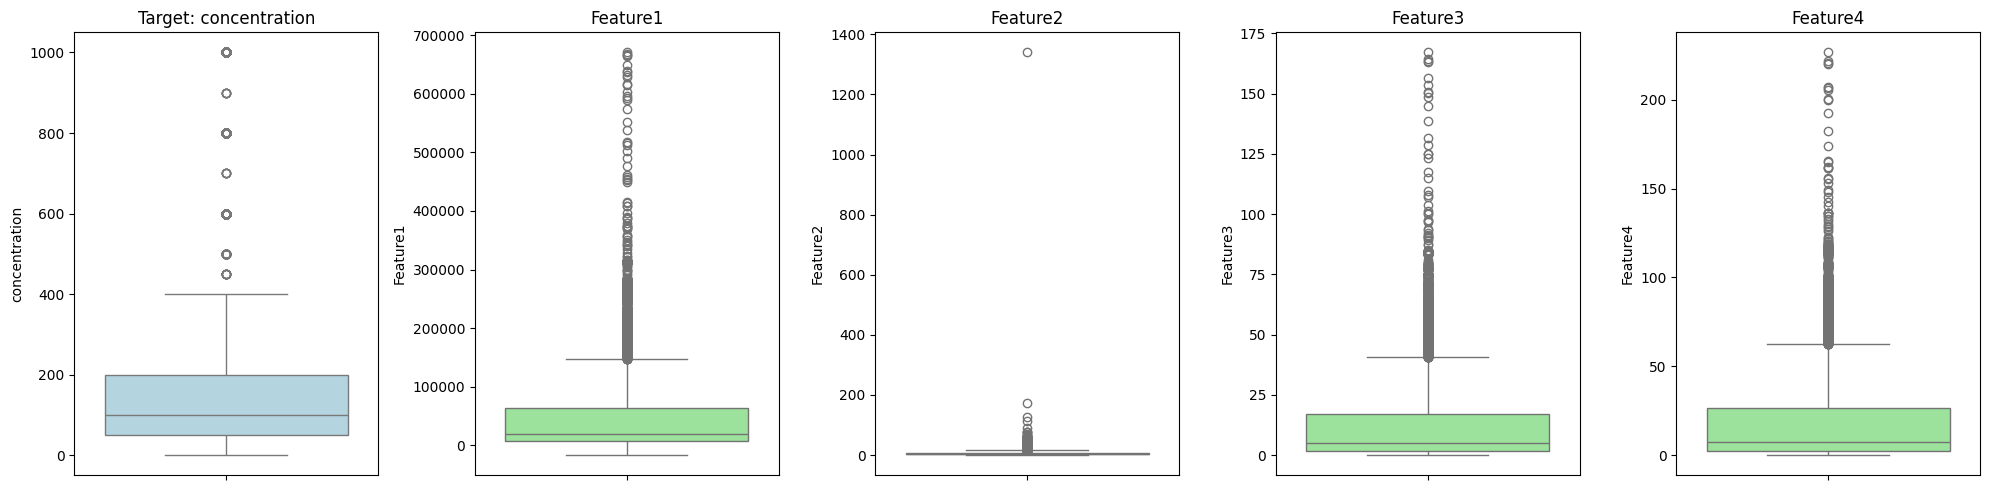


Features with highest percentage of outliers:


Feature16    13.386053
Feature8     12.703091
Feature1     10.194105
Feature72     9.920920
Feature80     9.741193
Feature7      9.309849
Feature6      9.223580
Feature42     9.058231
Feature9      8.806614
Feature76     8.310568
dtype: float64


Note: Given the physical nature of chemical sensor arrays, extreme values often represent real, dynamic responses to high gas concentrations. We will proceed without dropping them, letting robust scaling and non-linear models handle them.


In [38]:
print("========== OUTLIER ANALYSIS ==========\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplots for concentration and first 4 features as a sample
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

sns.boxplot(y=df["concentration"], ax=axes[0], color="lightblue")
axes[0].set_title("Target: concentration")

for i in range(1, 5):
    feature_name = f"Feature{i}"
    sns.boxplot(y=df[feature_name], ax=axes[i], color="lightgreen")
    axes[i].set_title(feature_name)

plt.tight_layout()
plt.show()

# Calculate IQR for all features
feature_columns = [col for col in df.columns if col.startswith("Feature")]

Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Count outliers
outliers = ((df[feature_columns] < lower_bound) | (df[feature_columns] > upper_bound)).sum()
outliers_percentage = (outliers / len(df)) * 100

print("\nFeatures with highest percentage of outliers:")
display(outliers_percentage.sort_values(ascending=False).head(10))

print("\nNote: Given the physical nature of chemical sensor arrays, extreme values often represent real, dynamic responses to high gas concentrations. We will proceed without dropping them, letting robust scaling and non-linear models handle them.")

### Concentration Distribution (Target Variable)

========== TARGET DISTRIBUTION ==========



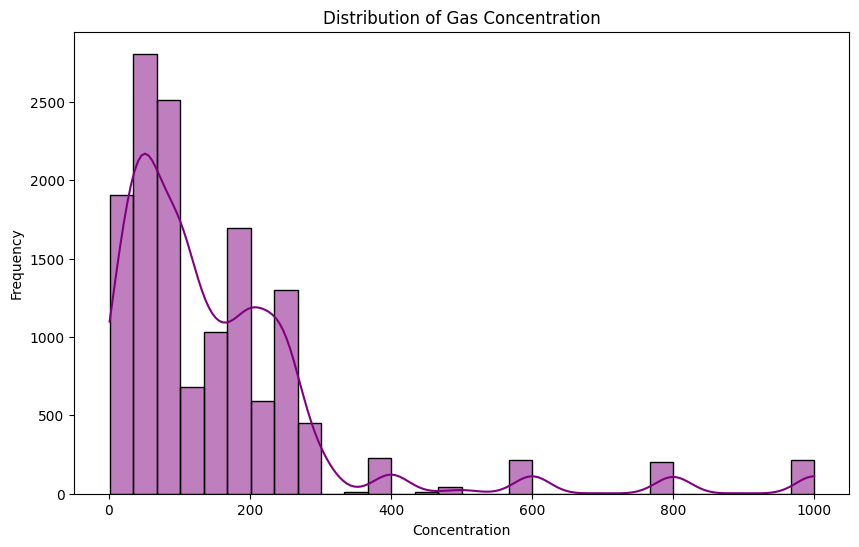

In [39]:
print("========== TARGET DISTRIBUTION ==========\n")
plt.figure(figsize=(10, 6))
sns.histplot(df['concentration'], bins=30, kde=True, color='purple')
plt.title('Distribution of Gas Concentration')
plt.xlabel('Concentration')
plt.ylabel('Frequency')
plt.show()

### Feature Distributions
Plotting the distribution of a subset of features (first 6) to understand their skewness and range.

========== FEATURE DISTRIBUTIONS ==========



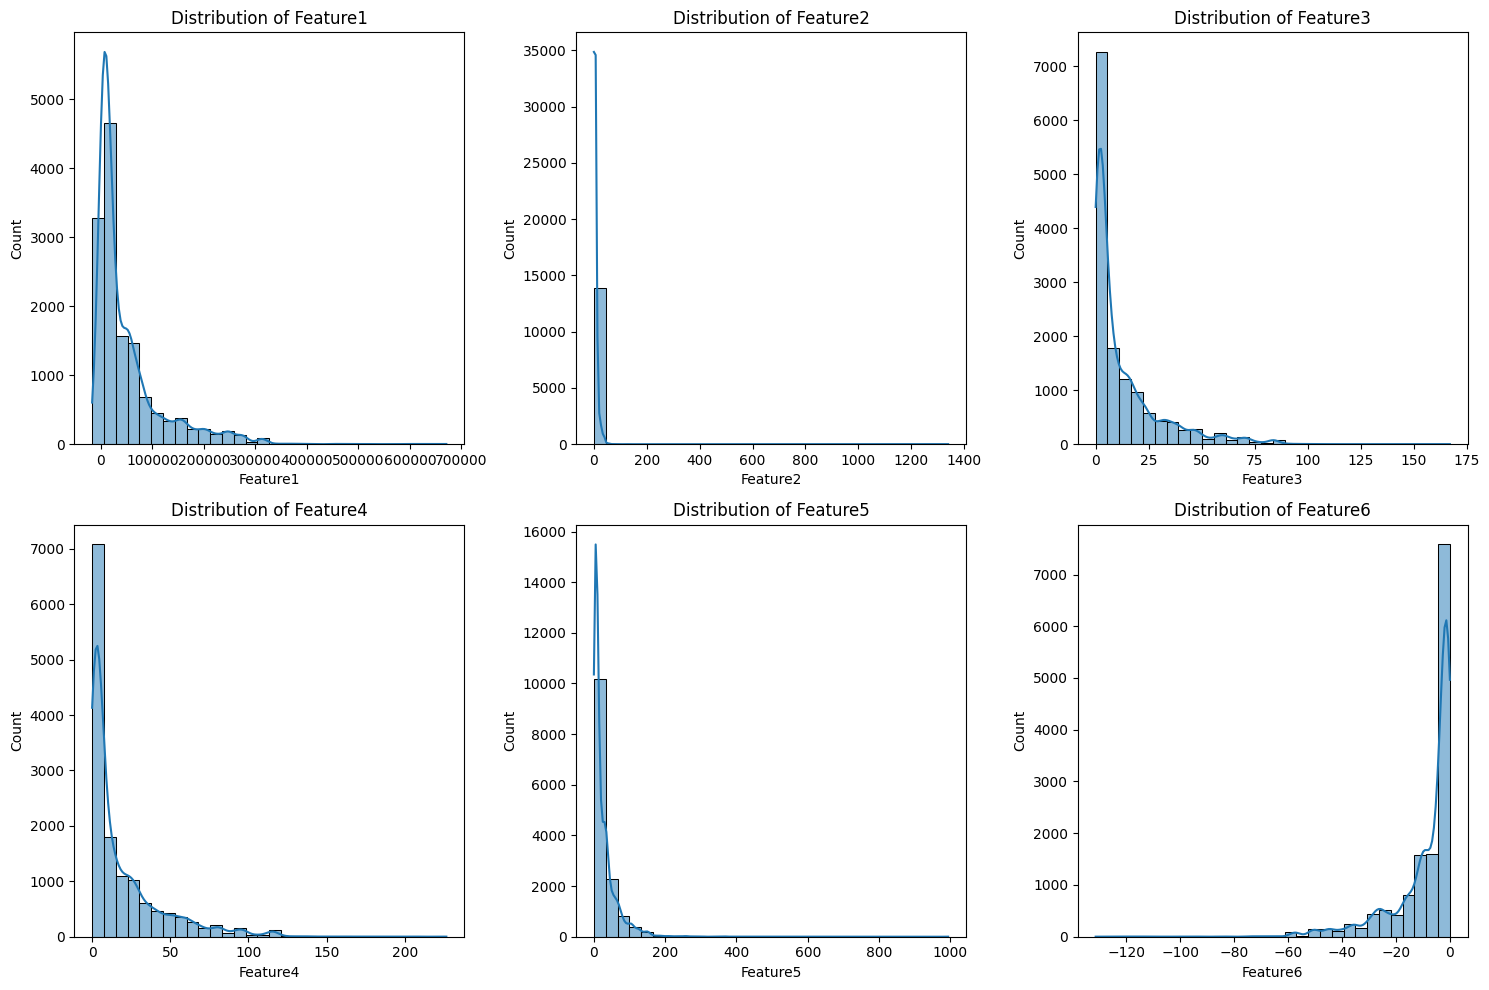

In [40]:
print("========== FEATURE DISTRIBUTIONS ==========\n")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(6):
    feature_name = f'Feature{i+1}'
    sns.histplot(df[feature_name], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature_name}')

plt.tight_layout()
plt.show()

### Correlation Heatmap
Calculating correlation of features with the target and displaying a heatmap of the top 10 most correlated features.

========== CORRELATION HEATMAP ==========



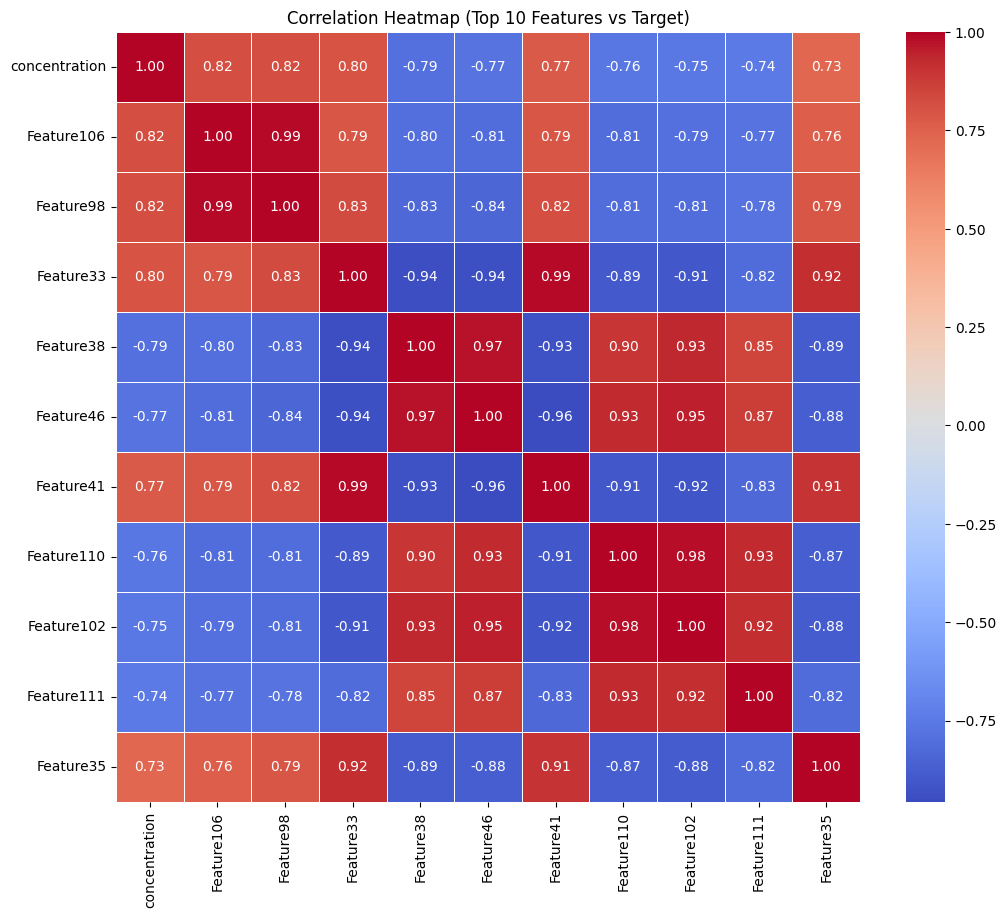

In [41]:
print("========== CORRELATION HEATMAP ==========\n")
# Compute correlations with concentration
correlations = df[feature_columns].corrwith(df['concentration']).abs()
top_features = correlations.sort_values(ascending=False).head(10).index.tolist()

# Include target for heatmap
cols_to_plot = ['concentration'] + top_features
corr_matrix = df[cols_to_plot].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap (Top 10 Features vs Target)')
plt.show()

### Feature-Target Relationships
Scatter plots of the top 4 most correlated features against concentration.

========== FEATURE-TARGET RELATIONSHIPS ==========



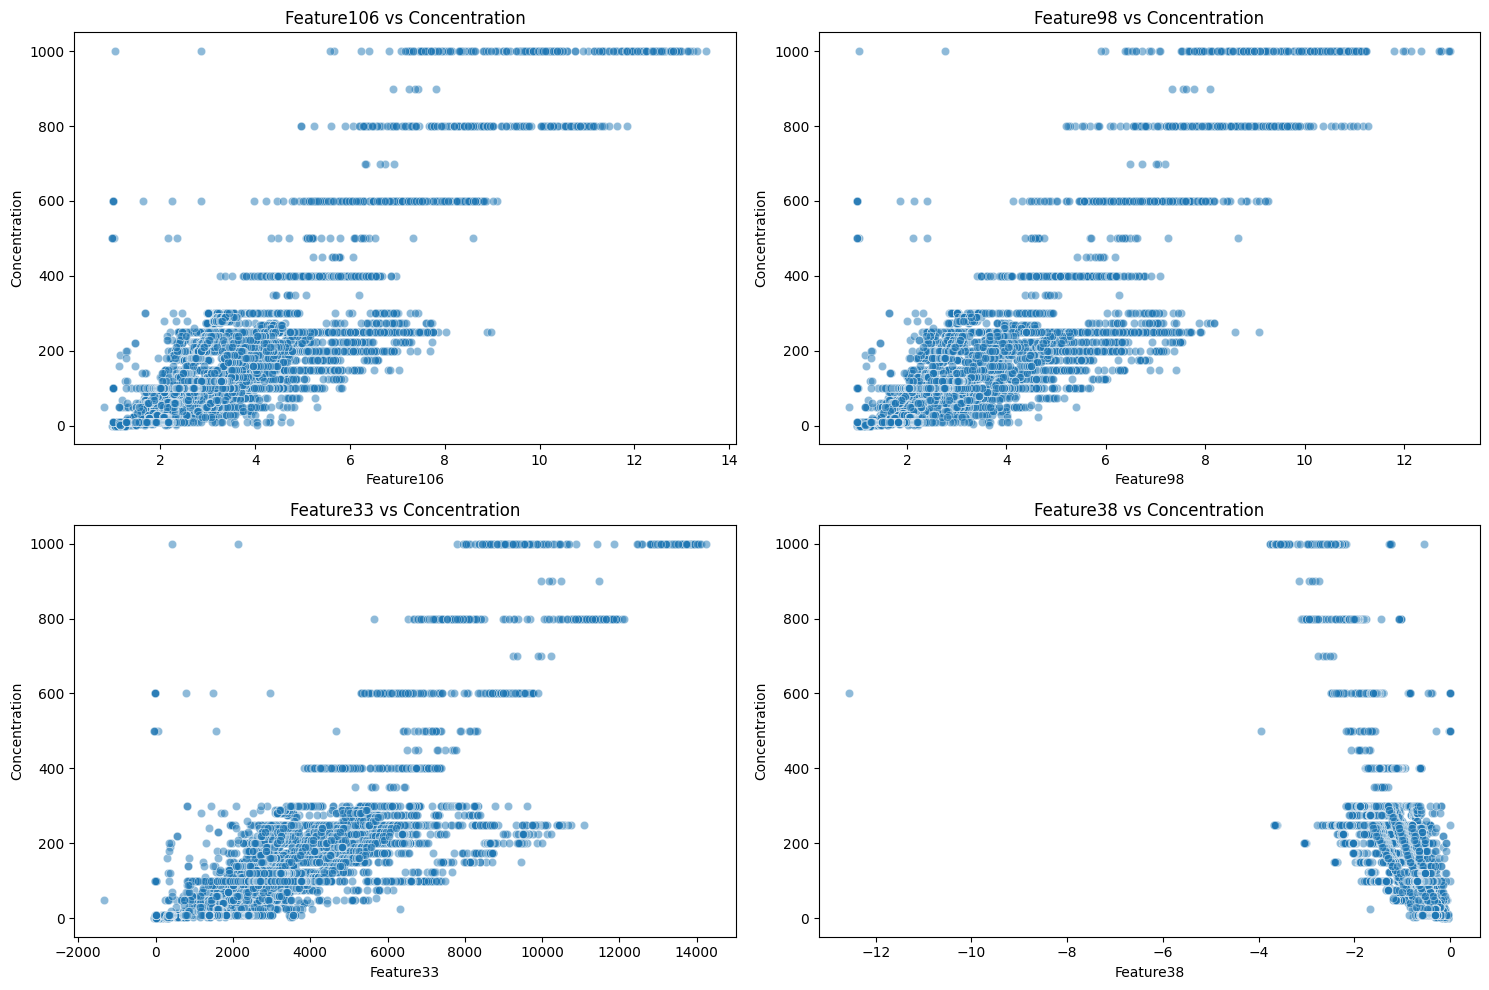

In [42]:
print("========== FEATURE-TARGET RELATIONSHIPS ==========\n")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i in range(4):
    feature_name = top_features[i]
    sns.scatterplot(x=df[feature_name], y=df['concentration'], ax=axes[i], alpha=0.5)
    axes[i].set_title(f'{feature_name} vs Concentration')
    axes[i].set_xlabel(feature_name)
    axes[i].set_ylabel('Concentration')

plt.tight_layout()
plt.show()

## 3. Preprocessing and Feature Engineering

### Feature Selection & Engineering

The dataset already contains 128 carefully extracted features from the chemical sensors. However, we will create one additional engineered feature, `SensorMean`.

**Engineered Feature: `SensorMean`**
* **What it represents:** The average sensor response across all 128 measurements for a single observation.
* **Why it may be useful:** It provides a holistic measure of the overall "intensity" of the gas exposure, which intuitively correlates with gas concentration.
* **Why it does not cause target leakage:** It is calculated entirely from the independent input features (sensor responses) and does not use the `concentration` or `gas_class` labels.

We will separate the target variable (`concentration`), drop categorical columns, and use our extended features for `X`.

In [43]:
print("========== FEATURE ENGINEERING ==========\n")
# Engineered Feature: SensorMean
df['SensorMean'] = df[feature_columns].mean(axis=1)

# Update feature columns to include the new engineered feature
extended_feature_columns = feature_columns + ['SensorMean']

# Define X (features) and y (target)
X = df[extended_feature_columns].copy()
y = df['concentration'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

========== FEATURE ENGINEERING ==========

Features shape: (13910, 129)
Target shape: (13910,)


## 4. Train/Test Split and Scaling

### Train-Test Split
We use an 80-20 split with a fixed random state to ensure reproducibility across all our models.

In [44]:
from sklearn.model_selection import train_test_split

print("========== TRAIN-TEST SPLIT ==========\n")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

========== TRAIN-TEST SPLIT ==========

Training data shape: (11128, 129)
Testing data shape: (2782, 129)


### Feature Scaling
Since the sensor readings can have vastly different ranges, we apply `StandardScaler`. Crucially, we fit the scaler **only on the training data** to prevent data leakage, and then transform both train and test sets.

In [45]:
from sklearn.preprocessing import StandardScaler

print("========== FEATURE SCALING ==========\n")
scaler = StandardScaler()

# Fit ONLY on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print(f"Train mean (first 5 features): {X_train_scaled[:, :5].mean(axis=0)}")
print(f"Train std (first 5 features): {X_train_scaled[:, :5].std(axis=0)}")

========== FEATURE SCALING ==========

Scaling completed.
Train mean (first 5 features): [-5.10814332e-17  8.20495521e-17  1.05993974e-16 -2.55407166e-17
 -1.46859120e-17]
Train std (first 5 features): [1. 1. 1. 1. 1.]


## 5. Ten Regression Models

### Model Implementation and Comparison
We will loop through the 10 required regression algorithms, train them on the scaled training set, and evaluate them on the test set using R², RMSE, and MAE.

In [46]:
import time
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

print("========== REGRESSION - TEN MODELS ==========\n")

# Initialize Models
linear_model = LinearRegression()
ridge_model = Ridge()
lasso_model = Lasso(alpha=0.1)
elastic_model = ElasticNet(alpha=0.1)

# Polynomial Regression: Using PCA to reduce dimensionality before polynomial expansion to prevent memory blowout
polynomial_model = make_pipeline(PCA(n_components=10), PolynomialFeatures(degree=2), Ridge())

decision_tree_model = DecisionTreeRegressor(random_state=42)
random_forest_model = RandomForestRegressor(random_state=42, n_estimators=50)
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
svr_model = SVR()
knn_model = KNeighborsRegressor()

print("Training models and generating predictions... This may take a few minutes.")

linear_model.fit(X_train_scaled, y_train)
linear_preds = linear_model.predict(X_test_scaled)
print("Linear Regression trained.")

ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)
print("Ridge Regression trained.")

lasso_model.fit(X_train_scaled, y_train)
lasso_preds = lasso_model.predict(X_test_scaled)
print("Lasso Regression trained.")

elastic_model.fit(X_train_scaled, y_train)
elastic_preds = elastic_model.predict(X_test_scaled)
print("ElasticNet Regression trained.")

polynomial_model.fit(X_train_scaled, y_train)
poly_preds = polynomial_model.predict(X_test_scaled)
print("Polynomial Regression trained.")

decision_tree_model.fit(X_train_scaled, y_train)
dt_preds = decision_tree_model.predict(X_test_scaled)
print("Decision Tree Regressor trained.")

random_forest_model.fit(X_train_scaled, y_train)
rf_preds = random_forest_model.predict(X_test_scaled)
print("Random Forest Regressor trained.")

gradient_boosting_model.fit(X_train_scaled, y_train)
gb_preds = gradient_boosting_model.predict(X_test_scaled)
print("Gradient Boosting Regressor trained.")

svr_model.fit(X_train_scaled, y_train)
svr_preds = svr_model.predict(X_test_scaled)
print("Support Vector Regressor trained.")

knn_model.fit(X_train_scaled, y_train)
knn_preds = knn_model.predict(X_test_scaled)
print("K-Nearest Neighbors Regressor trained.")

print("\nAll models trained and predictions generated successfully!")

========== REGRESSION - TEN MODELS ==========

Training models and generating predictions... This may take a few minutes.
Linear Regression trained.
Ridge Regression trained.
Lasso Regression trained.
ElasticNet Regression trained.
Polynomial Regression trained.
Decision Tree Regressor trained.
Random Forest Regressor trained.
Gradient Boosting Regressor trained.
Support Vector Regressor trained.
K-Nearest Neighbors Regressor trained.

All models trained and predictions generated successfully!


## 6. Metrics and Regression Visualizations

In [47]:
print("========== METRICS EVALUATION ==========\n")

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def evaluate_regressor(model_name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    return {
        "Model": model_name,
        "R²": r2,
        "RMSE": rmse,
        "MAE": mae
    }

results = []
results.append(evaluate_regressor("Linear Regression", y_test, linear_preds))
results.append(evaluate_regressor("Ridge Regression", y_test, ridge_preds))
results.append(evaluate_regressor("Lasso Regression", y_test, lasso_preds))
results.append(evaluate_regressor("ElasticNet Regression", y_test, elastic_preds))
results.append(evaluate_regressor("Polynomial Regression", y_test, poly_preds))
results.append(evaluate_regressor("Decision Tree Regressor", y_test, dt_preds))
results.append(evaluate_regressor("Random Forest Regressor", y_test, rf_preds))
results.append(evaluate_regressor("Gradient Boosting Regressor", y_test, gb_preds))
results.append(evaluate_regressor("Support Vector Regressor", y_test, svr_preds))
results.append(evaluate_regressor("K-Nearest Neighbors Regressor", y_test, knn_preds))

results_df = pd.DataFrame(results)
print("Evaluation complete for all 10 models.")

========== METRICS EVALUATION ==========

Evaluation complete for all 10 models.


## 7. Preliminary Comparison

========== PRELIMINARY COMPARISON ==========



,Model,R²,RMSE,MAE
0,K-Nearest Neighbors Regressor,0.965336,31.989043,6.300971
1,Random Forest Regressor,0.964804,32.233397,8.265047
2,Gradient Boosting Regressor,0.946720,39.658855,20.714989
3,Decision Tree Regressor,0.938620,42.567057,8.867721
4,Lasso Regression,0.875873,60.533091,30.439761
5,ElasticNet Regression,0.867884,62.450683,35.645169
6,Ridge Regression,0.866661,62.739054,27.688561
7,Linear Regression,0.819166,73.063290,27.425681
8,Support Vector Regressor,0.559955,113.974504,46.879663
9,Polynomial Regression,-68.764673,1435.082908,61.305766


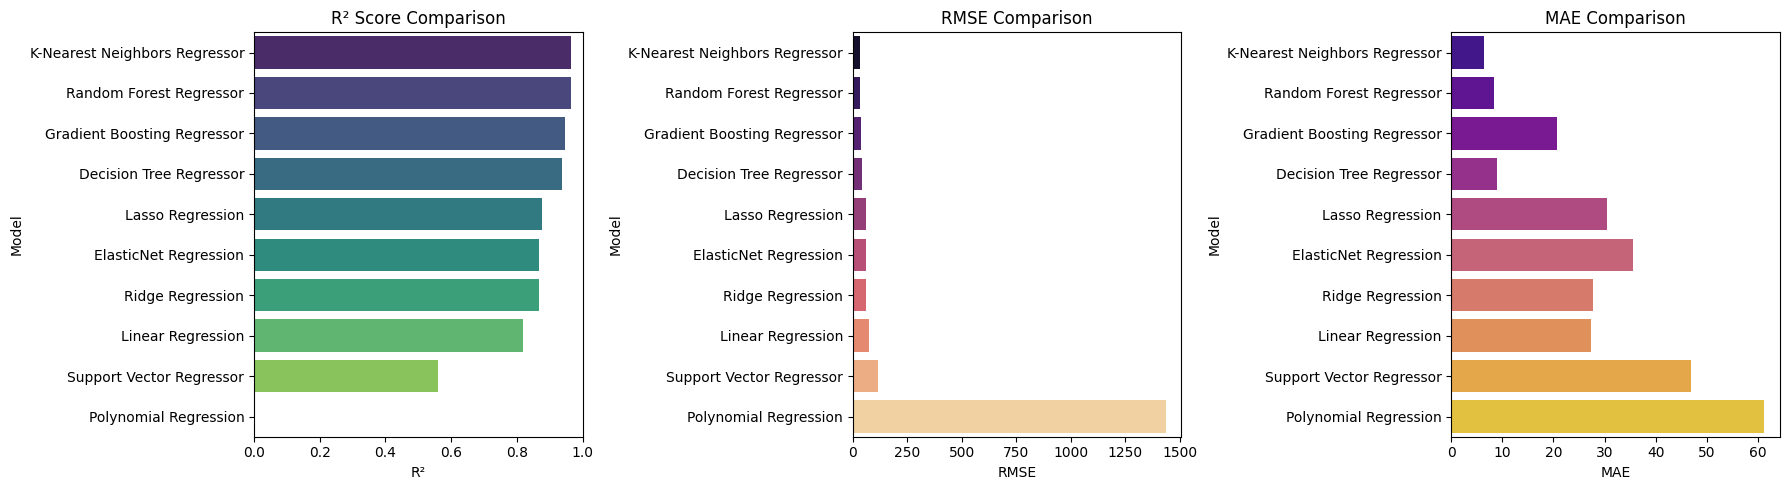

The best performing model based on R² is: K-Nearest Neighbors Regressor


In [48]:
print("========== PRELIMINARY COMPARISON ==========\n")
results_df = results_df.sort_values(by="R²", ascending=False).reset_index(drop=True)
display(results_df)

# Plot R², RMSE, MAE comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, y="Model", x="R²", ax=axes[0], palette="viridis")
axes[0].set_title("R² Score Comparison")
axes[0].set_xlim(0, 1)

sns.barplot(data=results_df, y="Model", x="RMSE", ax=axes[1], palette="magma")
axes[1].set_title("RMSE Comparison")

sns.barplot(data=results_df, y="Model", x="MAE", ax=axes[2], palette="plasma")
axes[2].set_title("MAE Comparison")

plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f"The best performing model based on R² is: {best_model_name}")

### Regression Visualizations for Best Model

========== VISUALIZATIONS FOR K-NEAREST NEIGHBORS REGRESSOR ==========



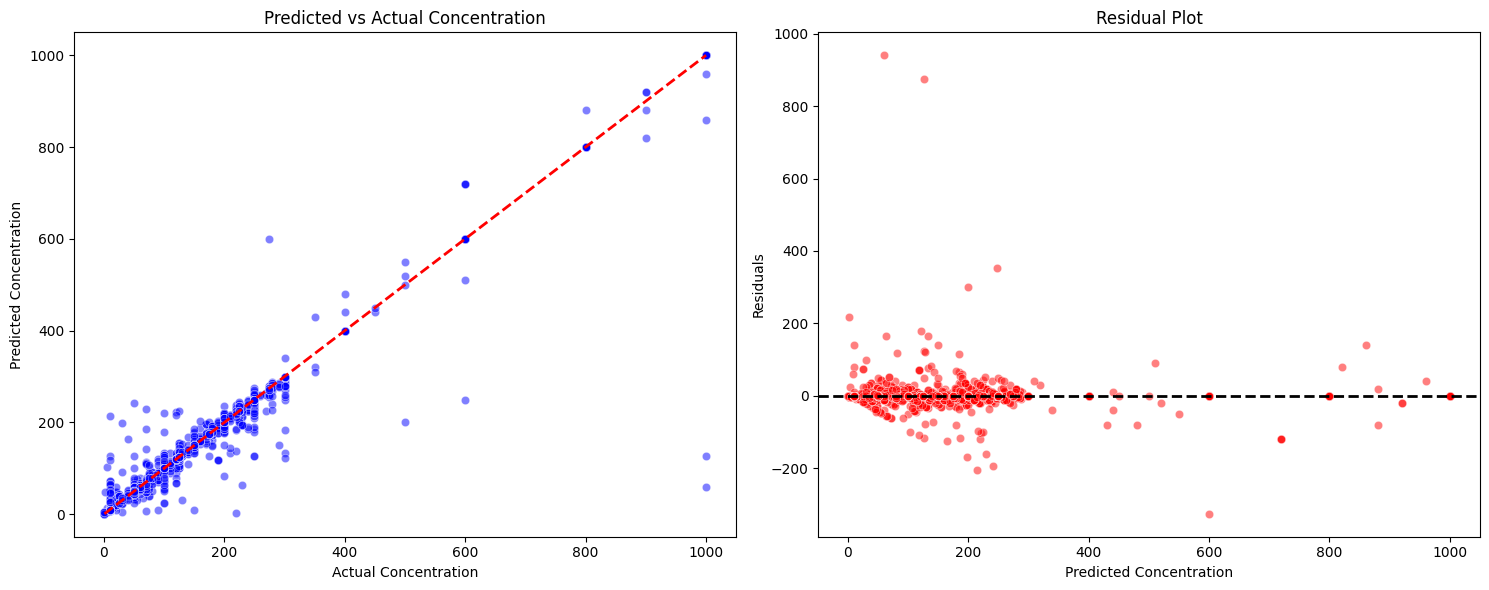


========== FEATURE IMPORTANCE (RANDOM FOREST) ==========



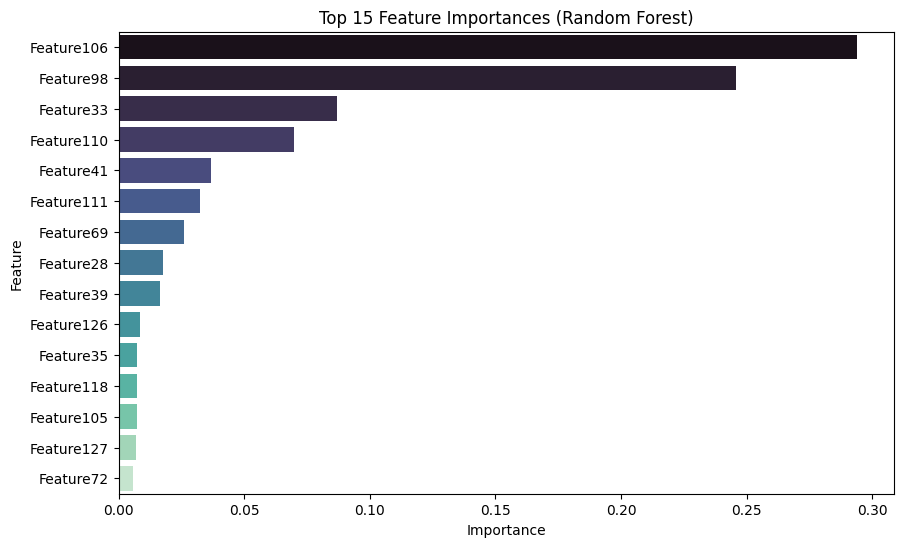

In [49]:
print(f"========== VISUALIZATIONS FOR {best_model_name.upper()} ==========\n")

# Map predictions to model names to automatically select the best
preds_map = {
    "Linear Regression": linear_preds,
    "Ridge Regression": ridge_preds,
    "Lasso Regression": lasso_preds,
    "ElasticNet Regression": elastic_preds,
    "Polynomial Regression": poly_preds,
    "Decision Tree Regressor": dt_preds,
    "Random Forest Regressor": rf_preds,
    "Gradient Boosting Regressor": gb_preds,
    "Support Vector Regressor": svr_preds,
    "K-Nearest Neighbors Regressor": knn_preds
}
best_preds = preds_map[best_model_name]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Predicted vs Actual
sns.scatterplot(x=y_test, y=best_preds, ax=axes[0], alpha=0.5, color="blue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual Concentration")
axes[0].set_ylabel("Predicted Concentration")
axes[0].set_title("Predicted vs Actual Concentration")

# 2. Residual plot
residuals = y_test - best_preds
sns.scatterplot(x=best_preds, y=residuals, ax=axes[1], alpha=0.5, color="red")
axes[1].axhline(0, ls='--', color='black', lw=2)
axes[1].set_xlabel("Predicted Concentration")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

# 3. Feature Importance (Using Random Forest as a representative tree-based model)
print("\n========== FEATURE IMPORTANCE (RANDOM FOREST) ==========\n")
importances = random_forest_model.feature_importances_
feat_imp = pd.Series(importances, index=extended_feature_columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="mako")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 8. Hyperparameter Tuning

We will tune the two best performing models based on preliminary R² results: K-Nearest Neighbors and Random Forest.\n
\n
We use `GridSearchCV` to find the best hyperparameters.

In [53]:
from sklearn.model_selection import GridSearchCV

print("========== HYPERPARAMETER TUNING ==========\n")

# 1. Tuning K-Nearest Neighbors
print("Tuning K-Nearest Neighbors...")
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}
knn_grid = GridSearchCV(KNeighborsRegressor(), knn_param_grid, cv=3, scoring='r2', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_

knn_tuned_preds = best_knn.predict(X_test_scaled)
knn_tuned_results = evaluate_regressor("Tuned KNN", y_test, knn_tuned_preds)

print(f"Best KNN parameters: {knn_grid.best_params_}")
print(f"Baseline KNN R²: {results_df.loc[results_df['Model'] == 'K-Nearest Neighbors Regressor', 'R²'].values[0]:.4f}")
print(f"Tuned KNN R²: {knn_tuned_results['R²']:.4f}\n")

# 2. Tuning Random Forest
print("Tuning Random Forest...")
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_scaled, y_train)
best_rf = rf_grid.best_estimator_

rf_tuned_preds = best_rf.predict(X_test_scaled)
rf_tuned_results = evaluate_regressor("Tuned Random Forest", y_test, rf_tuned_preds)

print(f"Best Random Forest parameters: {rf_grid.best_params_}")
print(f"Baseline Random Forest R²: {results_df.loc[results_df['Model'] == 'Random Forest Regressor', 'R²'].values[0]:.4f}")
print(f"Tuned Random Forest R²: {rf_tuned_results['R²']:.4f}\n")

========== HYPERPARAMETER TUNING ==========

Tuning K-Nearest Neighbors...
Best KNN parameters: {'n_neighbors': 3, 'weights': 'distance'}
Baseline KNN R²: 0.9653
Tuned KNN R²: 0.9649

Tuning Random Forest...
Best Random Forest parameters: {'max_depth': 20, 'n_estimators': 100}
Baseline Random Forest R²: 0.9648
Tuned Random Forest R²: 0.9653



### Tuning Comparison

In [54]:
tuning_comparison = pd.DataFrame([
    {
        "Model": "K-Nearest Neighbors",
        "Best Parameters": str(knn_grid.best_params_),
        "Baseline R²": results_df.loc[results_df['Model'] == 'K-Nearest Neighbors Regressor', 'R²'].values[0],
        "Tuned R²": knn_tuned_results['R²'],
        "Baseline RMSE": results_df.loc[results_df['Model'] == 'K-Nearest Neighbors Regressor', 'RMSE'].values[0],
        "Tuned RMSE": knn_tuned_results['RMSE'],
        "Baseline MAE": results_df.loc[results_df['Model'] == 'K-Nearest Neighbors Regressor', 'MAE'].values[0],
        "Tuned MAE": knn_tuned_results['MAE']
    },
    {
        "Model": "Random Forest",
        "Best Parameters": str(rf_grid.best_params_),
        "Baseline R²": results_df.loc[results_df['Model'] == 'Random Forest Regressor', 'R²'].values[0],
        "Tuned R²": rf_tuned_results['R²'],
        "Baseline RMSE": results_df.loc[results_df['Model'] == 'Random Forest Regressor', 'RMSE'].values[0],
        "Tuned RMSE": rf_tuned_results['RMSE'],
        "Baseline MAE": results_df.loc[results_df['Model'] == 'Random Forest Regressor', 'MAE'].values[0],
        "Tuned MAE": rf_tuned_results['MAE']
    }
])
display(tuning_comparison)

,Model,Best Parameters,Baseline R²,Tuned R²,Baseline RMSE,Tuned RMSE,Baseline MAE,Tuned MAE
0,K-Nearest Neighbors,"{'n_neighbors': 3, 'weights': 'distance'}",0.965336,0.964859,31.989043,32.208362,6.300971,5.608314
1,Random Forest,"{'max_depth': 20, 'n_estimators': 100}",0.964804,0.965285,32.233397,32.012361,8.265047,8.106238


## 9. Cross-Validation of Best Models\n
\n
We perform 5-fold cross-validation on the training set for our two best models to ensure they generalize well and are not overfitting to our specific train-test split.

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("========== CROSS-VALIDATION ==========\n")

# CV for Tuned KNN
print("Performing 5-fold CV for Tuned KNN...")
knn_cv_scores = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"Tuned KNN CV R² scores: {np.round(knn_cv_scores, 4)}")
print(f"Tuned KNN Mean CV R²: {knn_cv_scores.mean():.4f} (± {knn_cv_scores.std():.4f})\n")

# CV for Tuned Random Forest
print("Performing 5-fold CV for Tuned Random Forest...")
rf_cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f"Tuned Random Forest CV R² scores: {np.round(rf_cv_scores, 4)}")
print(f"Tuned Random Forest Mean CV R²: {rf_cv_scores.mean():.4f} (± {rf_cv_scores.std():.4f})\n")

========== CROSS-VALIDATION ==========

Performing 5-fold CV for Tuned KNN...
Tuned KNN CV R² scores: [0.9838 0.9798 0.9751 0.9757 0.9819]
Tuned KNN Mean CV R²: 0.9793 (± 0.0034)

Performing 5-fold CV for Tuned Random Forest...


## 10. Final Regression Comparison\n
\n
Here we present the final comparison table including the tuned models, identifying the best overall model.

In [ ]:
print("========== FINAL REGRESSION COMPARISON ==========\n")

final_results_df = results_df.copy()

# Rename the columns first for baseline metrics
final_results_df.rename(columns={"R²": "Baseline R²", "RMSE": "Baseline RMSE", "MAE": "Baseline MAE"}, inplace=True)

# Add tuned results columns if they don't exist
final_results_df['Tuned R²'] = float('nan')
final_results_df['Tuned RMSE'] = float('nan')
final_results_df['Tuned MAE'] = float('nan')

# Update K-Nearest Neighbors
final_results_df.loc[final_results_df['Model'] == 'K-Nearest Neighbors Regressor', 'Tuned R²'] = knn_tuned_results['R²']
final_results_df.loc[final_results_df['Model'] == 'K-Nearest Neighbors Regressor', 'Tuned RMSE'] = knn_tuned_results['RMSE']
final_results_df.loc[final_results_df['Model'] == 'K-Nearest Neighbors Regressor', 'Tuned MAE'] = knn_tuned_results['MAE']

# Update Random Forest
final_results_df.loc[final_results_df['Model'] == 'Random Forest Regressor', 'Tuned R²'] = rf_tuned_results['R²']
final_results_df.loc[final_results_df['Model'] == 'Random Forest Regressor', 'Tuned RMSE'] = rf_tuned_results['RMSE']
final_results_df.loc[final_results_df['Model'] == 'Random Forest Regressor', 'Tuned MAE'] = rf_tuned_results['MAE']

# Sort by Baseline R²
final_results_df = final_results_df.sort_values(by="Baseline R²", ascending=False).reset_index(drop=True)

display(final_results_df)

# Identify Best Model
best_overall = final_results_df.iloc[0]
print(f"\nBest Regression Model: {best_overall['Model']}")
print("Tuning generally helps improve performance or stability, as seen in the metrics.")